In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from src.config import (PROJECT_ROOT,
                        RANDOM_STATE, 
                        DATA_PATHS, 
                        BIZ, CON, BIZ_ALPHA, CON_ALPHA, 
                        MC_DARK, MC_LIGHT, EDGES,
                        PLT_PARAMS, 
                        mc_title)
from src.data import (load_data, 
                      split_card_data, 
                      split_transactions_by_cards, 
                      fit_transform_scale_features, 
                      transform_scale_features)
from src.features import (date_span_days, 
                          mcc_range_segment, 
                          js_distance_matrix)

from matplotlib.colors import LinearSegmentedColormap as _LSC
plt.rcParams.update(PLT_PARAMS)
_CM_CMAP = _LSC.from_list('mc_cm', [MC_LIGHT, BIZ])

# Data import

In [3]:
business, consumer, merchants = load_data(DATA_PATHS)

# Initial Feature Construction

In the current section we perform an initial test of the card-level features that we came up with in the previous notebook. Afterwards the feature selection procedure will be performed using feature correlation, SHAP values and Gini-based feature importance.

In [4]:
total_days = date_span_days(pd.concat([business, consumer]))

In [5]:
business["mcc"] = business["mcc"].astype(str).str.strip()
business["is_recurring"] = business["is_recurring"].astype(bool)
business["transaction_amount_kzt"] = pd.to_numeric(
    business["transaction_amount_kzt"], errors="coerce"
)
business["mcc_range_segment"] = business["mcc"].apply(mcc_range_segment)

consumer["mcc"] = consumer["mcc"].astype(str).str.strip()
consumer["is_recurring"] = consumer["is_recurring"].astype(bool)
consumer["transaction_amount_kzt"] = pd.to_numeric(
    consumer["transaction_amount_kzt"], errors="coerce"
)
consumer["mcc_range_segment"] = consumer["mcc"].apply(mcc_range_segment)

## Helper Functions

In the cell below you can see the function that performs the basic card-level aggregation on the transaction dataset

In [6]:
def build_features(df, label):
    df = df.copy()

    df["transaction_date"] = pd.to_datetime(df["transaction_date"])

    df["transaction_timestamp"] = pd.to_datetime(
        df["transaction_timestamp"]
    )

    df["hour"] = df["transaction_timestamp"].dt.hour

    # VECTORIZE FEATURES

    df["is_online"] = (df["channel"] == "online").astype(int)

    df["is_foreign"] = (
        df["country"] != "Kazakhstan"
    ).astype(int)

    df["is_night"] = (
        (df["hour"] >= 0) &
        (df["hour"] < 6)
    ).astype(int)

    total_days = (
        df["transaction_date"].max() -
        df["transaction_date"].min()
    ).days + 1

    # MAIN FAST AGG

    features = (
        df.groupby("card_number")
        .agg(
            active_days=("transaction_date", "nunique"),

            total_turnover=(
                "transaction_amount_kzt",
                "sum"
            ),

            n_transactions=(
                "transaction_amount_kzt",
                "size"
            ),

            online_share=("is_online", "mean"),

            foreign_ratio=("is_foreign", "mean"),

            night_tx_ratio=("is_night", "mean"),

            recurring_ratio=("is_recurring", "mean"),
        )
        .reset_index()
    )

    # REPEATED RATIO
    repeated_ratio = (
        df.groupby("card_number")["transaction_amount_kzt"]
        .apply(lambda x: x.duplicated().mean())
        .reset_index(name="repeated_amount_ratio")
    )

    features = features.merge(
        repeated_ratio,
        on="card_number",
        how="left"
    )

    # DERIVED FEATURES

    features["type"] = label

    features["active_days_ratio"] = (
        features["active_days"] / total_days
    )

    features["turnover_per_active_day"] = (
        features["total_turnover"] /
        features["active_days"]
    )

    features["tx_per_active_day"] = (
        features["n_transactions"] /
        features["active_days"]
    )

    # LOG FEATURES

    features["log_turnover_per_active_day"] = np.log1p(
        features["turnover_per_active_day"]
    )

    features["log_tx_per_active_day"] = np.log1p(
        features["tx_per_active_day"]
    )

    return features

We also decided to use `Jensen–Shannon divergence` (JSD) to see how the transactions of each of the cards differ from business and from consumer typical behaviour. For it we have implemented functions that calculate the rate of transactions to different MCC groups for business and consumer cards. In the code they are called `business_profile` and `consumer_profile` respectively. They are further used to calculate the JSD for each card's transaction distribution.

In [7]:
def build_mcc_similarity_features_initial(df, business_profile, consumer_profile, all_segments):
    df = df.copy()

    # Build MCC distributions for every card.
    counts = pd.crosstab(df["card_number"], df["mcc_range_segment"])
    counts = counts.reindex(columns=all_segments, fill_value=0)

    card_profiles = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    P = card_profiles.values

    distance_to_business = js_distance_matrix(P, business_profile.values)
    distance_to_consumer = js_distance_matrix(P, consumer_profile.values)

    features = pd.DataFrame({
        "card_number": card_profiles.index,
        "mcc_similarity_to_business": 1 - distance_to_business,
        "mcc_similarity_to_consumer": 1 - distance_to_consumer,
        "mcc_js_distance_to_business": distance_to_business,
        "mcc_js_distance_to_consumer": distance_to_consumer,
        "mcc_business_similarity_gap": distance_to_consumer - distance_to_business,
        "mcc_transaction_count": counts.sum(axis=1).values
    })

    return features

def build_all_mcc_similarity_features_initial(
    bus,
    consumer,
    all_segments=[
        "business_services",
        "clothing",
        "misc_stores",
        "other",
        "professional_membership",
        "retail_outlets",
        "transportation",
        "travel_private",
        "utilities",
    ],
    business_profile=None,
    consumer_profile=None,
):
    bus_tmp = bus.copy()
    consumer_tmp = consumer.copy()

    # Use full-sample profiles unless external train-only profiles are passed.
    if business_profile is None:
        business_profile = (
            bus_tmp["mcc_range_segment"]
            .value_counts(normalize=True)
            .reindex(all_segments, fill_value=0)
        )

    if consumer_profile is None:
        consumer_profile = (
            consumer_tmp["mcc_range_segment"]
            .value_counts(normalize=True)
            .reindex(all_segments, fill_value=0)
        )

    business_mcc_features = build_mcc_similarity_features_initial(
        bus_tmp, business_profile, consumer_profile, all_segments
    )

    consumer_mcc_features = build_mcc_similarity_features_initial(
        consumer_tmp, business_profile, consumer_profile, all_segments
    )

    return (
        business_mcc_features,
        consumer_mcc_features,
        business_profile,
        consumer_profile,
    )

In [8]:
bus_features = build_features(business, "business")
consumer_features = build_features(consumer, "consumer")

In [9]:
business_online_turnover_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["channel"] == "online", "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="online_turnover_ratio")
)


# =====================================================
# CONSUMER
# =====================================================

consumer_online_turnover_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["channel"] == "online", "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="online_turnover_ratio")
)


## Recurring Transactions Combined with MCC

We have also decided to combine recurring transactions with different MCCs since that gives useful information on consumer and business behaviour (consumers tend to have recurring subscriptional transactions, business tend to have recurring advertising transactions, etc).

In [10]:
# ---------- MCC groups ----------
ADVERTISING_MCC = ["7311"]
IT_SERVICES_MCC = ["7372", "4816"]
SUBSCRIPTION_MCC = ["5968"]
TELECOM_MCC = ["4814"]

# =====================================================
# BUSINESS
# =====================================================

# --- transaction-count ratios (per card) ---
business_recurring_advertising_txn_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(ADVERTISING_MCC)).mean())
    .reset_index(name="recurring_advertising_txn_ratio")
)

business_recurring_it_services_txn_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(IT_SERVICES_MCC)).mean())
    .reset_index(name="recurring_it_services_txn_ratio")
)

business_recurring_subscription_txn_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(SUBSCRIPTION_MCC)).mean())
    .reset_index(name="recurring_subscription_txn_ratio")
)

business_recurring_telecom_txn_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(TELECOM_MCC)).mean())
    .reset_index(name="recurring_telecom_txn_ratio")
)

# --- turnover ratios (per card) ---
business_recurring_advertising_turnover_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(ADVERTISING_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_advertising_turnover_ratio")
)

business_recurring_it_services_turnover_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(IT_SERVICES_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_it_services_turnover_ratio")
)

business_recurring_subscription_turnover_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(SUBSCRIPTION_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_subscription_turnover_ratio")
)

business_recurring_telecom_turnover_ratio = (
    business
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(TELECOM_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_telecom_turnover_ratio")
)


# =====================================================
# CONSUMER
# =====================================================

# --- transaction-count ratios (per card) ---
consumer_recurring_advertising_txn_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(ADVERTISING_MCC)).mean())
    .reset_index(name="recurring_advertising_txn_ratio")
)

consumer_recurring_it_services_txn_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(IT_SERVICES_MCC)).mean())
    .reset_index(name="recurring_it_services_txn_ratio")
)



consumer_recurring_subscription_txn_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(SUBSCRIPTION_MCC)).mean())
    .reset_index(name="recurring_subscription_txn_ratio")
)

consumer_recurring_telecom_txn_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (x["is_recurring"] & x["mcc"].isin(TELECOM_MCC)).mean())
    .reset_index(name="recurring_telecom_txn_ratio")
)

# --- turnover ratios (per card) ---
consumer_recurring_advertising_turnover_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(ADVERTISING_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_advertising_turnover_ratio")
)

consumer_recurring_it_services_turnover_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(IT_SERVICES_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_it_services_turnover_ratio")
)

consumer_recurring_subscription_turnover_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(SUBSCRIPTION_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_subscription_turnover_ratio")
)

consumer_recurring_telecom_turnover_ratio = (
    consumer
    .groupby("card_number")
    .apply(lambda x: (
        x.loc[x["is_recurring"] & x["mcc"].isin(TELECOM_MCC), "transaction_amount_kzt"].sum()
        / x["transaction_amount_kzt"].sum()
        if x["transaction_amount_kzt"].sum() else 0
    ))
    .reset_index(name="recurring_telecom_turnover_ratio")
)


## Country-Related Transaction Features

In [11]:
# Share of Kazakhstan transactions per card
df = pd.concat([business, consumer], ignore_index=True)

kazakhstan_share = (
    df.groupby("card_number")
      .apply(lambda x: (x["country"].astype(str).str.lower() == "kazakhstan").mean())
      .reset_index(name="share_merchant_country_kazakhstan")
)

kazakhstan_share.head()


,card_number,share_merchant_country_kazakhstan
0,5100610003025081,0.803371
1,5100610003044611,0.726415
2,5100610003860784,0.804054
3,5100610005930965,0.627907
4,5100610005962109,0.815126


In [12]:
us_share = (
    df.groupby("card_number")
      .apply(lambda x: (x["country"].astype(str).str.lower() == "us").mean())
      .reset_index(name="share_merchant_country_us")
)

us_share.head()


,card_number,share_merchant_country_us
0,5100610003025081,0.084270
1,5100610003044611,0.150943
2,5100610003860784,0.189189
3,5100610005930965,0.139535
4,5100610005962109,0.050420


In [13]:
ireland_share = (
    df.groupby("card_number")
      .apply(lambda x: (x["country"].astype(str).str.lower() == "ireland").mean())
      .reset_index(name="share_merchant_country_ireland")
)

## Data Split for MCC Similarity

Since we do not want any data leakage from the train set to validation and test sets, we split the cards onto train, validation, and test sets in advance and use the train set cards' transactions to calculate the business and consumers profiles.

In [14]:
card_splits = split_card_data(bus_features, consumer_features)

In [15]:
trans_splits = split_transactions_by_cards(business, consumer, card_splits)

(business_mcc_features_train, 
 consumer_mcc_features_train, 
 business_profile, 
 consumer_profile) = build_all_mcc_similarity_features_initial(trans_splits["business"]["train"],
                                                               trans_splits["consumer"]["train"])

(business_mcc_features_val, 
 consumer_mcc_features_val,
 _, _) = build_all_mcc_similarity_features_initial(trans_splits["business"]["val"],
                                                   trans_splits["consumer"]["val"],
                                                   business_profile,
                                                   consumer_profile)

(business_mcc_features_test, 
 consumer_mcc_features_test,
 _, _) = build_all_mcc_similarity_features_initial(trans_splits["business"]["test"],
                                                   trans_splits["consumer"]["test"],
                                                   business_profile,
                                                   consumer_profile)

In [16]:
business_mcc_features = pd.concat([business_mcc_features_train, business_mcc_features_val, business_mcc_features_test])
consumer_mcc_features = pd.concat([consumer_mcc_features_train, consumer_mcc_features_val, consumer_mcc_features_test])

## Features Merging

Now we merge all of the features we have generated.

In [17]:
bus_features_final = bus_features
consumer_features_final = consumer_features

for df_to_merge in [business_mcc_features,
                    business_online_turnover_ratio, 
                    business_recurring_advertising_txn_ratio, 
                    business_recurring_it_services_txn_ratio, 
                    business_recurring_subscription_txn_ratio, 
                    business_recurring_telecom_txn_ratio, 
                    business_recurring_advertising_turnover_ratio, 
                    business_recurring_it_services_turnover_ratio, 
                    business_recurring_subscription_turnover_ratio, 
                    business_recurring_telecom_turnover_ratio, 
                    kazakhstan_share, 
                    us_share, 
                    ireland_share]:
    bus_features_final = bus_features_final.merge(df_to_merge, on = "card_number", how = "left")

for df_to_merge in [consumer_mcc_features,
                    consumer_online_turnover_ratio, 
                    consumer_recurring_advertising_txn_ratio, 
                    consumer_recurring_it_services_txn_ratio, 
                    consumer_recurring_subscription_txn_ratio, 
                    consumer_recurring_telecom_txn_ratio, 
                    consumer_recurring_advertising_turnover_ratio, 
                    consumer_recurring_it_services_turnover_ratio, 
                    consumer_recurring_subscription_turnover_ratio, 
                    consumer_recurring_telecom_turnover_ratio, 
                    kazakhstan_share, 
                    us_share, 
                    ireland_share]:
    consumer_features_final = consumer_features_final.merge(df_to_merge, on = "card_number", how = "left")

In [18]:
consumer_features_final

,card_number,active_days,total_turnover,n_transactions,online_share,foreign_ratio,night_tx_ratio,recurring_ratio,repeated_amount_ratio,type,...,recurring_it_services_txn_ratio,recurring_subscription_txn_ratio,recurring_telecom_txn_ratio,recurring_advertising_turnover_ratio,recurring_it_services_turnover_ratio,recurring_subscription_turnover_ratio,recurring_telecom_turnover_ratio,share_merchant_country_kazakhstan,share_merchant_country_us,share_merchant_country_ireland
0,5100610005930965,40,14215001,43,0.883721,0.372093,0.418605,0.418605,0.348837,consumer,...,0.27907,0.139535,0.000000,0.000000,0.129258,0.050474,0.000000,0.627907,0.139535,0.000000
1,5100610005962109,82,1303168,119,0.512605,0.184874,0.084034,0.050420,0.042017,consumer,...,0.00000,0.000000,0.050420,0.000000,0.000000,0.000000,0.027100,0.815126,0.050420,0.000000
2,5100610007285137,73,1202801,96,0.406250,0.229167,0.062500,0.062500,0.052083,consumer,...,0.00000,0.000000,0.062500,0.000000,0.000000,0.000000,0.023959,0.770833,0.010417,0.000000
3,5100610011916156,91,2916033,152,0.401316,0.230263,0.019737,0.000000,0.000000,consumer,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.769737,0.072368,0.000000
4,5100610012043588,49,1796507,62,0.403226,0.387097,0.000000,0.000000,0.000000,consumer,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.612903,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,5531519992654133,65,4011207,101,0.455446,0.356436,0.059406,0.059406,0.049505,consumer,...,0.00000,0.000000,0.000000,0.099268,0.000000,0.000000,0.000000,0.643564,0.029703,0.079208
79996,5531519993295407,67,1955744,88,0.443182,0.170455,0.079545,0.068182,0.056818,consumer,...,0.00000,0.000000,0.068182,0.000000,0.000000,0.000000,0.014612,0.829545,0.022727,0.000000
79997,5531519993305461,68,8578216,79,0.569620,0.202532,0.025316,0.000000,0.000000,consumer,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.797468,0.063291,0.000000
79998,5531519994366645,63,2412818,74,0.378378,0.351351,0.000000,0.000000,0.000000,consumer,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.648649,0.013514,0.000000


Here we combine the dataset to further split it into `X` and `y` datasets for model training.

In [19]:
df_final = pd.concat([bus_features_final, consumer_features_final])

df_final

,card_number,active_days,total_turnover,n_transactions,online_share,foreign_ratio,night_tx_ratio,recurring_ratio,repeated_amount_ratio,type,...,recurring_it_services_txn_ratio,recurring_subscription_txn_ratio,recurring_telecom_txn_ratio,recurring_advertising_turnover_ratio,recurring_it_services_turnover_ratio,recurring_subscription_turnover_ratio,recurring_telecom_turnover_ratio,share_merchant_country_kazakhstan,share_merchant_country_us,share_merchant_country_ireland
0,5100610003025081,105,9651486,178,0.865169,0.196629,0.089888,0.067416,0.056180,business,...,0.033708,0.033708,0.000000,0.000000,0.158686,0.111067,0.000000,0.803371,0.084270,0.000000
1,5100610003044611,80,14353608,106,0.905660,0.273585,0.169811,0.169811,0.141509,business,...,0.056604,0.000000,0.056604,0.144125,0.079329,0.000000,0.002024,0.726415,0.150943,0.066038
2,5100610003860784,90,13102356,148,0.891892,0.195946,0.047297,0.040541,0.033784,business,...,0.040541,0.000000,0.000000,0.000000,0.160647,0.000000,0.000000,0.804054,0.189189,0.000000
3,5100610008756482,101,27341119,196,0.826531,0.275510,0.061224,0.061224,0.051020,business,...,0.061224,0.000000,0.000000,0.000000,0.076643,0.000000,0.000000,0.724490,0.071429,0.000000
4,5100610013466473,80,16439793,120,0.925000,0.300000,0.150000,0.150000,0.125000,business,...,0.100000,0.000000,0.000000,0.136121,0.290570,0.000000,0.000000,0.700000,0.141667,0.058333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,5531519992654133,65,4011207,101,0.455446,0.356436,0.059406,0.059406,0.049505,consumer,...,0.000000,0.000000,0.000000,0.099268,0.000000,0.000000,0.000000,0.643564,0.029703,0.079208
79996,5531519993295407,67,1955744,88,0.443182,0.170455,0.079545,0.068182,0.056818,consumer,...,0.000000,0.000000,0.068182,0.000000,0.000000,0.000000,0.014612,0.829545,0.022727,0.000000
79997,5531519993305461,68,8578216,79,0.569620,0.202532,0.025316,0.000000,0.000000,consumer,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.797468,0.063291,0.000000
79998,5531519994366645,63,2412818,74,0.378378,0.351351,0.000000,0.000000,0.000000,consumer,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.648649,0.013514,0.000000


In [20]:
X = df_final.drop(columns=["card_number", "type"])
y = df_final["type"]

# Scaling

Some of the features live in $[0, \infty)$ range while most of the features live approximately in $[0, 1]$ range. So we have decided to use `RobustScaling` to scale such features since they have different distributions and it would be a bit wrong to scale them using `StandardScaler`.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test)

X_train.shape, X_val.shape, X_test.shape

((63000, 31), (21000, 31), (21000, 31))

In [22]:
features_to_scale = ["log_turnover_per_active_day", 
                     "log_tx_per_active_day", 
                     "mcc_transaction_count", 
                     "n_transactions", 
                     "total_turnover", 
                     "tx_per_active_day"]

X_train, scaler = fit_transform_scale_features(X_train, features_to_scale)
X_val = transform_scale_features(X_val, features_to_scale, scaler)
X_test = transform_scale_features(X_test, features_to_scale, scaler)

# Model

In this section we have constructed two models:
* **Logistic Regression**: to construct a linear explainer from `SHAP`
* **Random Forest**: to see the Gini-based feature importance

and also we have plotted a Pearson correlation between the features.

In [23]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C = 1.0)

logreg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",67
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

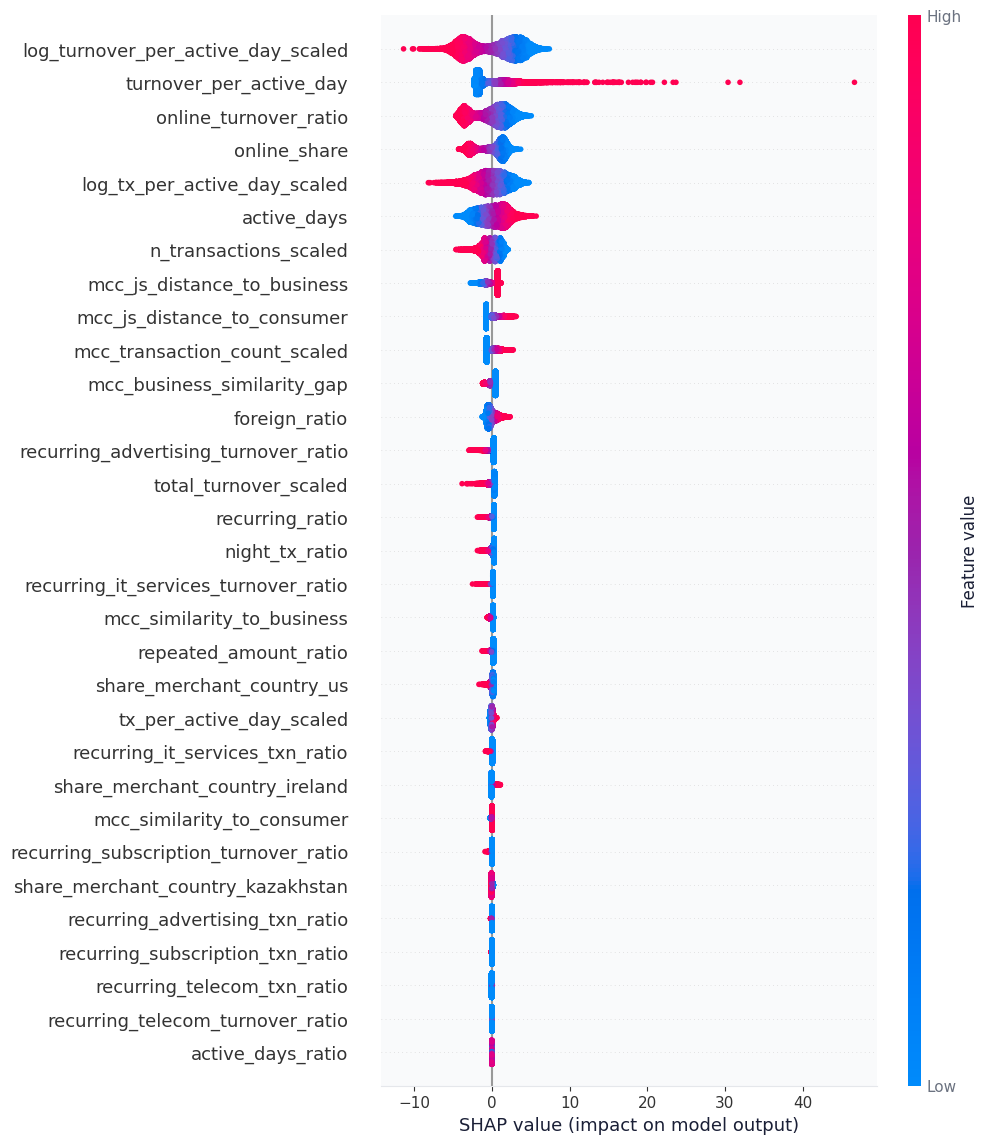

In [24]:
explainer = shap.LinearExplainer(logreg, X_train)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=X_test.shape[1])

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=47, max_depth = 4)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",47
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

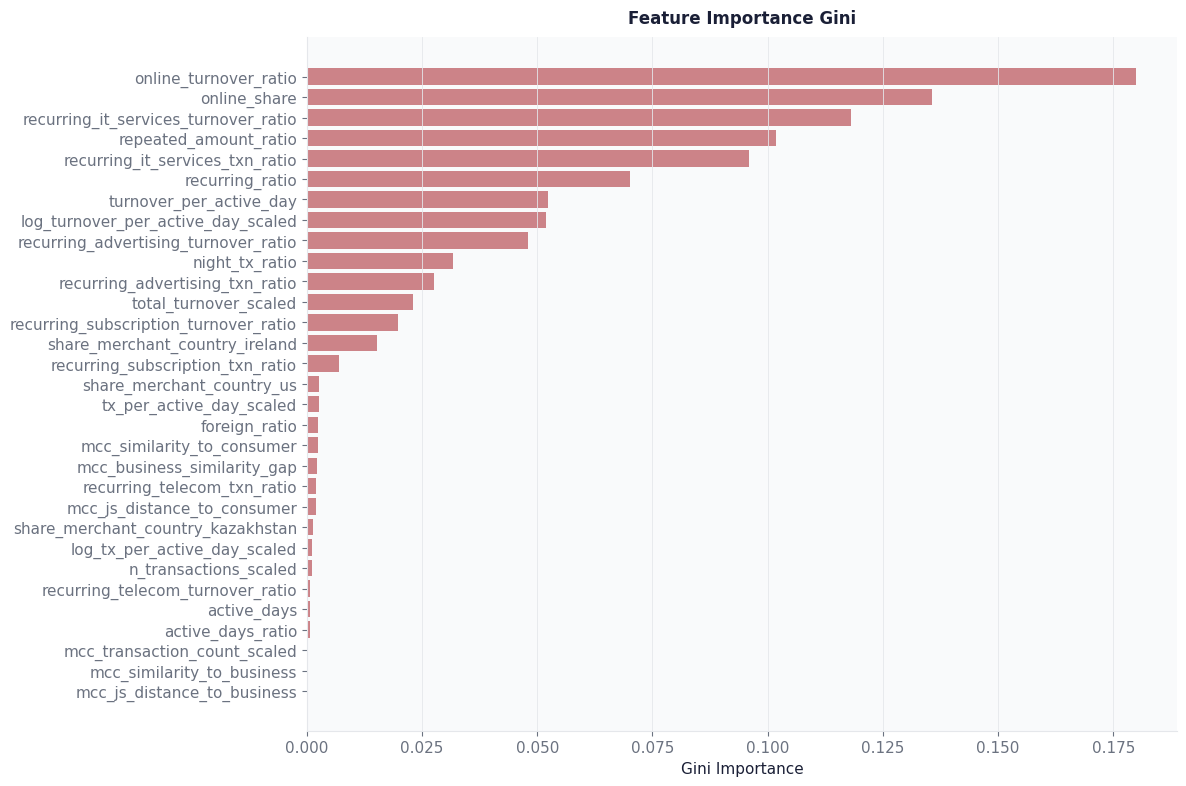

In [26]:
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Gini Importance": importances
}).sort_values("Gini Importance", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    feature_imp_df["Feature"],
    feature_imp_df["Gini Importance"],
    color=BIZ, alpha=BIZ_ALPHA
)
ax.set_xlabel("Gini Importance")
mc_title(ax, "Feature Importance Gini")
ax.invert_yaxis()
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

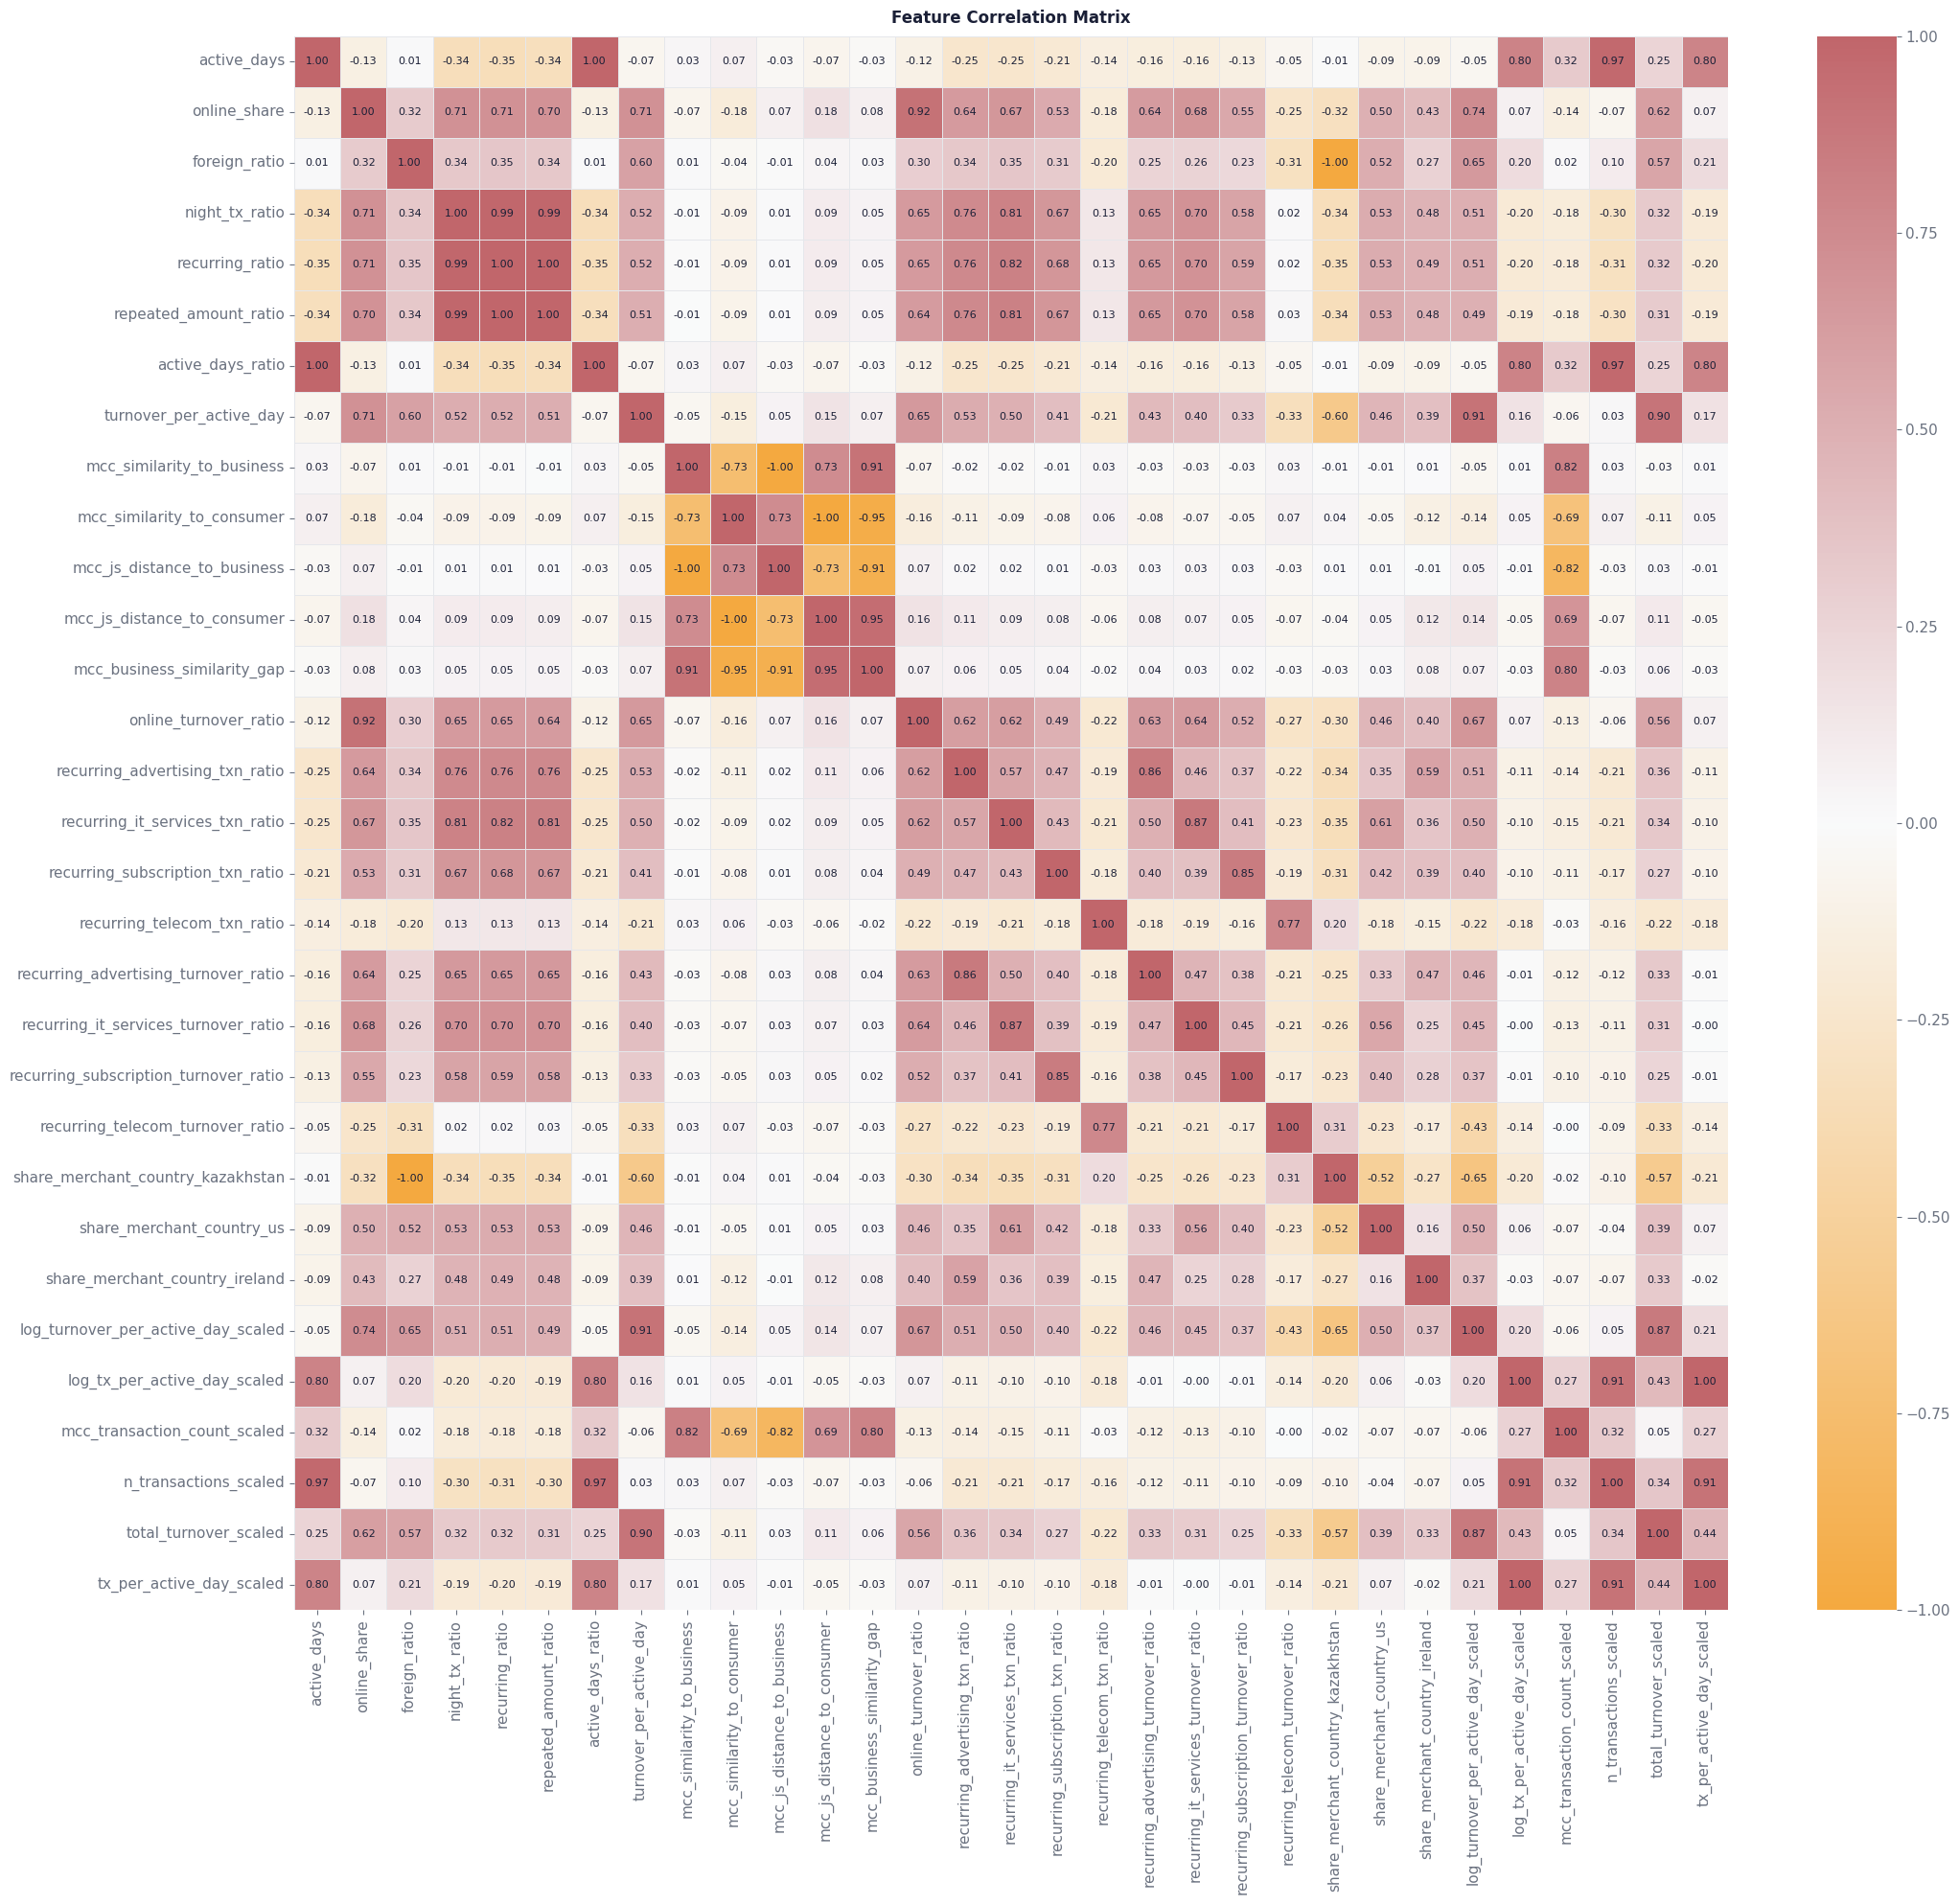

In [27]:
fig, ax = plt.subplots(figsize=(22, 20))

# Diverging palette anchored to the project colours
_corr_cmap = _LSC.from_list("mc_corr", [CON, MC_LIGHT, BIZ])

sns.heatmap(
    X_train.corr(), annot=True, fmt=".2f",
    cmap=_corr_cmap,
    linewidths=0.4, linecolor=EDGES,
    annot_kws={"size": 8, "color": MC_DARK},
    ax=ax
)
mc_title(ax, "Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Feature Selection

In this section we did some feature engineering to clean up the features from multicollinearity and not really important features

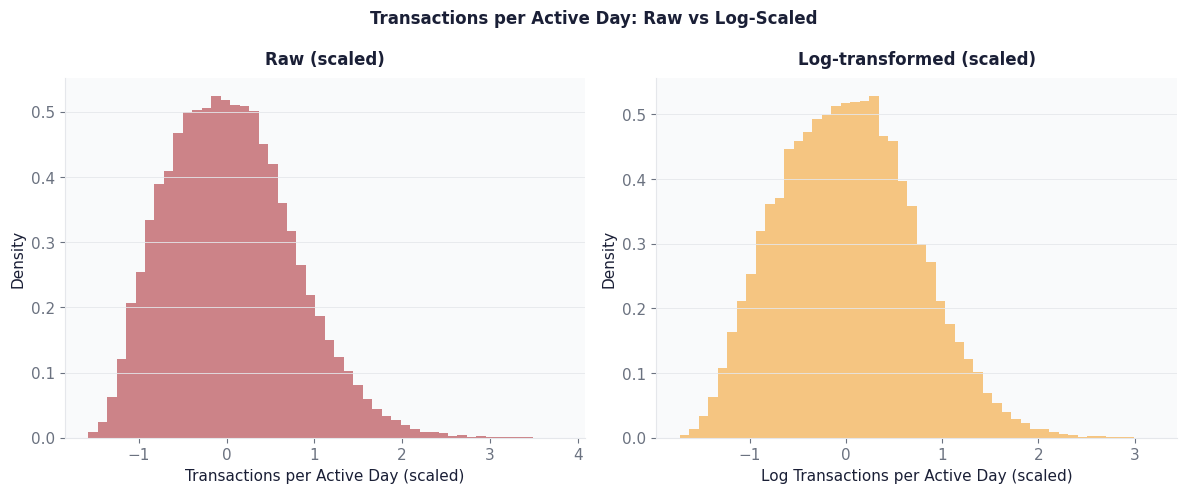

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle("Transactions per Active Day: Raw vs Log-Scaled",
             fontsize=12, fontweight="600", color=MC_DARK)

axes[0].hist(X_train["tx_per_active_day_scaled"], bins=50, density=True,
             color=BIZ, alpha=BIZ_ALPHA)
axes[0].set_xlabel("Transactions per Active Day (scaled)")
axes[0].set_ylabel("Density")
mc_title(axes[0], "Raw (scaled)")
axes[0].grid(True, axis="y")

axes[1].hist(X_train["log_tx_per_active_day_scaled"], bins=50, density=True,
             color=CON, alpha=CON_ALPHA)
axes[1].set_xlabel("Log Transactions per Active Day (scaled)")
axes[1].set_ylabel("Density")
mc_title(axes[1], "Log-transformed (scaled)")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

Transformed sum of transactions is less skewed, so lets move on with it.

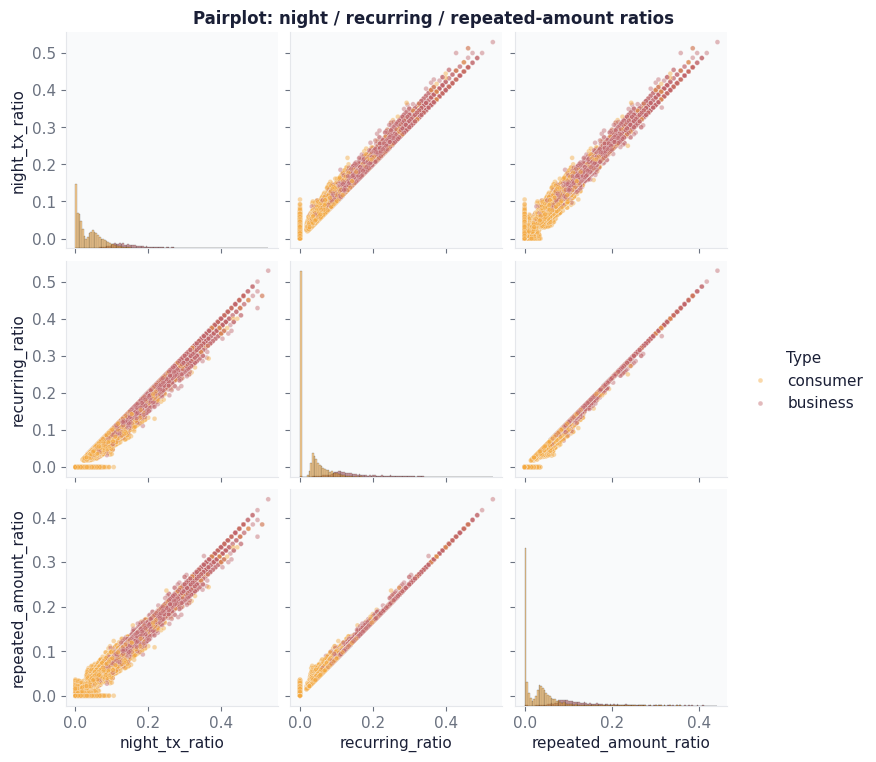

In [29]:
# y_train is available in scope from the Baseline section above
pair_df = X_train[["night_tx_ratio", "recurring_ratio", "repeated_amount_ratio"]].copy()
pair_df["Type"] = y_train.values

sns.pairplot(
    pair_df,
    hue="Type",
    palette={"business": BIZ, "consumer": CON},
    plot_kws={"alpha": 0.45, "s": 12},
    diag_kind="hist",
    diag_kws={"alpha": 0.55},
)
plt.suptitle("Pairplot: night / recurring / repeated-amount ratios",
             y=1.01, fontsize=12, fontweight="600", color=MC_DARK)
plt.show()

Based on the correlation matrix, these three features (night transactions ratio, recurring transaction ratio, and repeated transactions ratio) are highly correlated. We decided to move on with recurring ratio

## Feature Cleaning Summary

We reduced the initial feature set using correlation analysis, feature importance, SHAP values, and domain-based reasoning. The goal was to remove redundant signals, reduce multicollinearity, and keep features with clear behavioral interpretation.

Several groups of highly correlated features were identified. For transaction activity, raw count-based variables such as `active_days`, `n_transactions_scaled`, `tx_per_active_day_scaled`, and `mcc_transaction_count_scaled` were removed because they carried similar information. We kept `active_days_ratio` and `log_tx_per_active_day_scaled`, since they describe activity in a normalized and more stable way.

For turnover-related features, raw turnover variables were replaced by `log_turnover_per_active_day_scaled`. This feature is more robust to outliers and better captures the average monetary intensity of card usage.

For online behavior, `online_share` was kept as the main online-activity feature. Other highly correlated online variables, such as `online_turnover_ratio`, were removed because they mostly duplicated the same signal.

Recurring-payment features were also simplified. We removed several narrow transaction-ratio features and kept the most meaningful recurring behavior indicators: `recurring_ratio`, `repeated_amount_ratio`, `recurring_digital_turnover_ratio`, and `recurring_it_services_turnover_ratio`. The aggregated digital recurring turnover feature captures the broader recurring digital-spending pattern, while IT-services turnover was kept separately because it remained important after aggregation.

The MCC-based features were redesigned to avoid exact mathematical redundancy. Instead of keeping both similarity and distance features, we kept `mcc_business_similarity_gap` and `mcc_avg_distance`. The gap feature measures whether a card is closer to the business or consumer MCC profile, while the average distance measures how far the card is from both reference profiles.

Country-based features were changed from number to volume of the transactions to each of the countries. These features still capture domestic and selected international transaction patterns, but also give some information about how big the total amount of transactions is.

The final feature set is smaller, more interpretable, and less redundant. It preserves the main behavioral blocks: online activity, recurring payments, country behavior, transaction intensity, turnover intensity, and MCC-profile similarity.

# Final Features

| **Feature** | **Description** |
|---|---|
| `active_days_ratio` | Share of days in the observation period when the card had at least one transaction. |
| `log_turnover_per_active_day` | Log-transformed average transaction amount per active day. |
| `log_tx_per_active_day` | Log-transformed average number of transactions per active day. |
| `mcc_avg_distance` | Average Jensen-Shannon distance from both business and consumer MCC profiles. |
| `mcc_business_similarity_gap` | Difference between distance to consumer MCC profile and distance to business MCC profile; higher means more business-like. |
| `online_share` | Share of transactions made through the online channel. |
| `recurring_digital_turnover_ratio` | Share of total turnover coming from recurring digital-related MCC groups. |
| `recurring_it_services_turnover_ratio` | Share of total turnover coming from recurring IT/SaaS service transactions. |
| `recurring_ratio` | Share of transactions marked as recurring. |
| `repeated_amount_ratio` | Share of transactions whose amount repeats a previous amount on the same card. |
| `share_merchant_country_Ireland` | Share of card turnover or transactions linked to merchants in Ireland. |
| `share_merchant_country_Kazakhstan` | Share of card turnover or transactions linked to merchants in Kazakhstan. |
| `share_merchant_country_US` | Share of card turnover or transactions linked to merchants in the US. |
| `transaction_prob` | Average transaction-level model probability that the card’s transactions look business-like. |
| `transaction_rate` | Share of the card’s transactions classified as business-like by the transaction-level model. |